about Wayne-whaley's toy barometer [link](https://www.equities.com/impact-investing/wayne-whaley-s-toy-barometer/)

if we created a features, how do we know it is a consistent predictive factors not an overfitting, out sample test have a consistent predictive power

rolling correlation should be consistent

but how do we find the right performance regime before we find out?

in the macro-ops, it give multiple signals for 1year horizon predictions. 

Looks, we only need focus on given time horizon, and then keep find the factors that works

In [106]:
from sts.data import yh_data
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [123]:
ref_month = 2
pred_month = 12

In [125]:
spy_df = yh_data.get_hist_data_for_symbols(["SPY"], sd=datetime.date(1950, 1, 1), ed=datetime.date(2024, 3, 17))
spy_df.index = pd.to_datetime(spy_df.index)
spy_df["logSPY"] = np.log(spy_df["SPY"])

In [126]:
spy_df["year"] = spy_df.index.year
spy_df["month"] = spy_df.index.month
spy_df["day"] = spy_df.index.day

In [127]:
spy_df = spy_df.reset_index()  # avoid lost of index when merge

In [128]:
spy_df["prevDate"] = spy_df["Date"] - pd.DateOffset(months=ref_month)
spy_df = pd.merge_asof(
    spy_df,
    spy_df[["Date", "logSPY"]].rename(columns={"Date": "prevDate", "logSPY": "prevLogSPY"}),
    on="prevDate",
)

In [129]:
spy_df["predDate"] = spy_df["Date"] + pd.DateOffset(months=pred_month)
spy_df = pd.merge_asof(
    spy_df,
    spy_df[["Date", "logSPY"]].rename(columns={"Date": "predDate", "logSPY": "predLogSPY"}),
    on="predDate",
)

In [130]:
spy_df = spy_df.dropna()

In [131]:
spy_df["Y"] = spy_df["predLogSPY"] - spy_df["logSPY"]
spy_df["DY"] = spy_df["logSPY"] - spy_df["prevLogSPY"]

In [264]:
pattern = spy_df[(spy_df["month"] == 12) & (spy_df["day"] <= 19)].groupby("year").last()

In [265]:
pattern["signal"] = np.where(
    pattern["DY"] >= 0.03,
    1,
    np.where(pattern["DY"] >= 0, 0, np.where(pattern["DY"] < 0, -1, np.nan)),
)

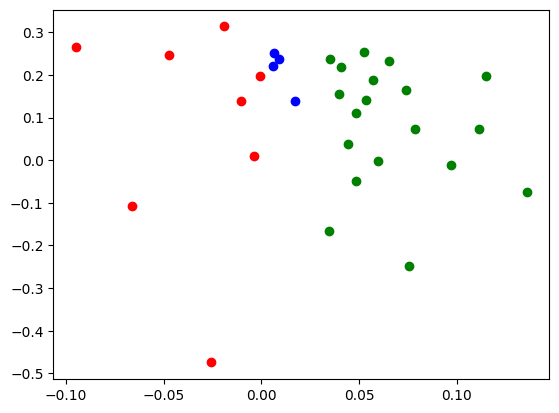

In [266]:
for signal, c in zip([-1, 0, 1], ["r", "b", "g"]):
    df = pattern[pattern["signal"] == signal]
    plt.scatter(df["DY"], df["Y"], c=c)

why Jan? not other month?


let's check the pattern, scan 
* prediction horizon
* how consistent cross historical data points


it seems hard to use xgboost to find pattern in noise data. 

idea like zscore, x-square test  something like this might be helpful

In [ ]:
for n in range(1, 13, 1):
    df = pattern[spy_df.month == n]
    df[["Y", "DY"]].corr()

,Date,SPY,logSPY,month,day,prevDate,prevLogSPY,predDate,predLogSPY,Y,DY,signal
year,,,,,,,,,,,,
1997,1997-01-17,48.006779,3.871342,1,17,1996-11-17,3.819844,1998-01-17,4.103198,0.231856,0.051499,1.0
1998,1998-01-16,60.533566,4.103198,1,16,1997-11-16,4.064900,1999-01-16,4.371790,0.268592,0.038298,1.0
1999,1999-01-19,79.702499,4.378301,1,19,1998-11-19,4.296605,2000-01-19,4.549622,0.171321,0.081696,1.0
2000,2000-01-19,94.596649,4.549622,1,19,1999-11-19,4.516080,2001-01-19,4.467608,-0.082015,0.033542,1.0
2004,2004-01-16,77.670647,4.352477,1,16,2003-11-16,4.267881,2005-01-16,4.405949,0.053471,0.084596,1.0
2006,2006-01-19,90.483192,4.505164,1,19,2005-11-19,4.474781,2007-01-19,4.630624,0.125460,0.030383,1.0
2010,2010-01-19,88.185989,4.479448,1,19,2009-11-19,4.427468,2011-01-19,4.607417,0.127968,0.051980,1.0
2011,2011-01-19,100.224884,4.607417,1,19,2010-11-19,4.538096,2012-01-19,4.652900,0.045484,0.069321,1.0
2012,2012-01-19,104.888741,4.652900,1,19,2011-11-19,4.571733,2013-01-19,4.795569,0.142669,0.081167,1.0
